# For each data file, which time steps to select?

We cannot use `xr.open_mfdataset()` since the time steps overlap (see figure below). 

In [1]:
%matplotlib widget
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from utils import get_boundary_slice, plot_2boundary_slice
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 18

### Open three files from March 2024 and compare

In [ ]:
year = 2024
month = '03'
dir = f'https://thredds.met.no/thredds/dodsC/foccus/'

outer = 0

files = [f'{dir}/norshelf-ana_fwd_{year}{month}{date}T00Z_outer{outer}.nc' for date in [10,11,12]]
drop_vars = ['AKs','AKt','AKv','Cs_r','Cs_w','DU_avg1','DU_avg2','DV_avg1','DV_avg2','h','hc','s_w','temp','temp_obc','u','u_obc','ubar','ubar_obc','v','v_obc','vbar','vbar_obc','zeta','zeta_obc']
# Which means these are included:
# lat_rho,lat_u,lat_v,lon_rho,lon_u,lon_v,ocean_time,s_rho,
# salt,salt_obc

# Include more variables:
#drop_vars = ['AKs','AKt','AKv','Cs_r','Cs_w','DU_avg1','DU_avg2','DV_avg1','DV_avg2','h','hc','s_w']
# Which means these are included:
# lat_rho,lat_u,lat_v,lon_rho,lon_u,lon_v,ocean_time,
# s_rho,salt,salt_obc,temp,temp_obc,u,u_obc,ubar,ubar_obc,v,v_obc,vbar,vbar_obc,zeta,zeta_obc

In [ ]:
ds10 = xr.open_dataset(files[0], drop_variables=drop_vars, chunks={'ocean_time': -1})
ds11 = xr.open_dataset(files[1], drop_variables=drop_vars, chunks={'ocean_time': -1})
ds12 = xr.open_dataset(files[2], drop_variables=drop_vars, chunks={'ocean_time': -1})

In [ ]:
time10 = ds10.ocean_time.values
time11 = ds11.ocean_time.values
time12 = ds12.ocean_time.values

### Plot the time steps and how they overlap

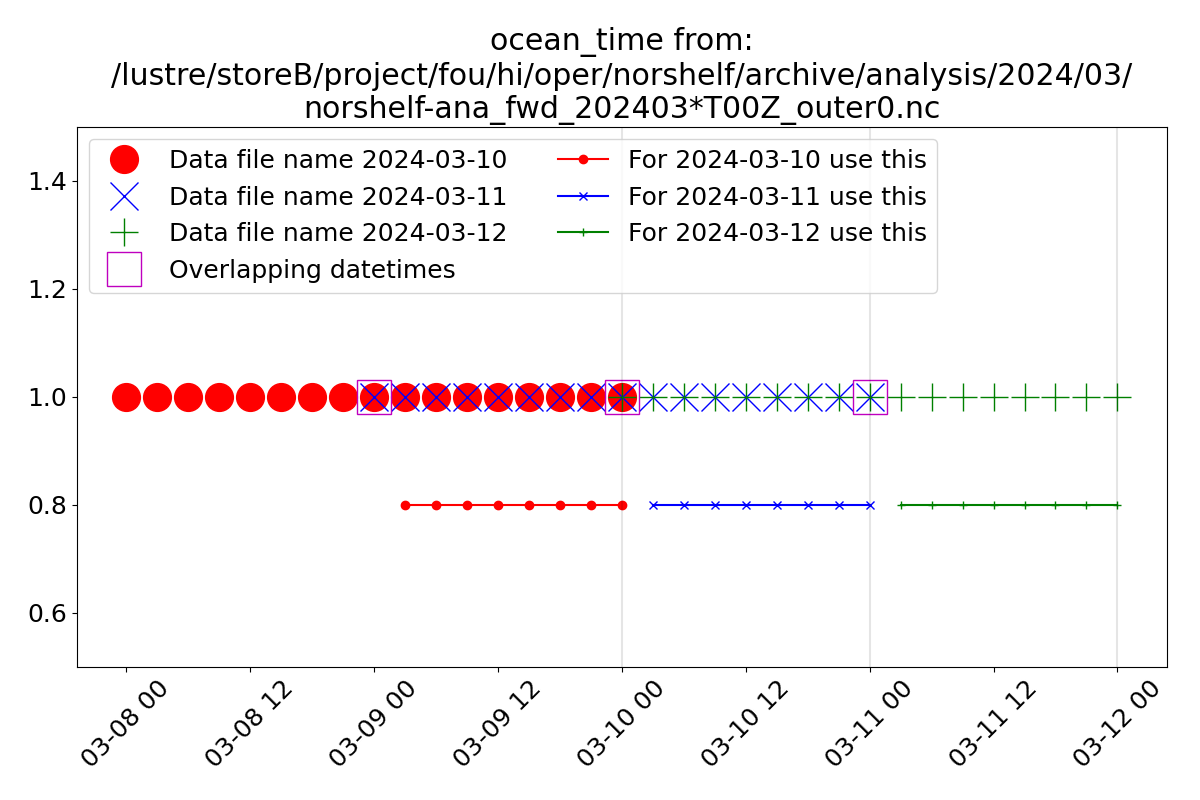

In [ ]:
fig, ax = plt.subplots(1)
ydata = np.ones(17)

kwargs = {'markersize': 20}
ax.plot(time10,ydata,'ro',label="Data file name 2024-03-10", **kwargs)
ax.plot(time11,ydata,'bx',label="Data file name 2024-03-11", **kwargs)
ax.plot(time12,ydata,'g+',label="Data file name 2024-03-12", **kwargs)

# plot the data points that overlap
kwargs2 = {'markersize': 25,'fillstyle': 'none'}
ax.plot(time10[8],ydata[8],'ms',label="Overlapping datetimes", **kwargs2)
ax.plot(time11[8],ydata[8],'ms', **kwargs2)
ax.plot(time12[8],ydata[8],'ms', **kwargs2)

# plot lines indicating which datetimes to use for each file
ax.plot(time10[-8:],ydata[-8:]*0.8,'ro-',label="For 2024-03-10 use this")
ax.plot(time11[-8:],ydata[-8:]*0.8,'bx-',label="For 2024-03-11 use this")
ax.plot(time12[-8:],ydata[-8:]*0.8,'g+-',label="For 2024-03-12 use this")

#ax.plot(time10[-1],ydata[8],'ys',label="In all data files", markersize=30, fillstyle='none')

#plot a few gray lines
ax.plot([time10[-1],time10[-1]],[-1,2],'k',alpha=0.1)
ax.plot([time11[-1],time11[-1]],[-1,2],'k',alpha=0.1)
ax.plot([time12[-1],time12[-1]],[-1,2],'k',alpha=0.1)

ax.tick_params(axis='x', labelrotation=45)
ax.set_ylim([0.5,1.5])

t = 'ocean_time from:\nhttps://thredds.met.no/thredds/dodsC/foccus/\nnorshelf-ana_fwd_202403*T00Z_outer0.nc'
plt.title(t)
plt.legend(ncols=2)
plt.tight_layout()

In [24]:
ind_time = np.arange(17)[-8:]
ind_time

array([ 9, 10, 11, 12, 13, 14, 15, 16])

In [25]:
salt10 = ds10.salt.isel(ocean_time=ind_time)
salt11 = ds11.salt.isel(ocean_time=ind_time)
salt12 = ds12.salt.isel(ocean_time=ind_time)

### Concat the datasets and compare to data opened separately

In [ ]:
# Open datasets in parallel using Dask
selected_datasets = []

for file in files:
    ds_one = xr.open_dataset(file, drop_variables=drop_vars, chunks={'ocean_time': -1})
    selected_ds = ds_one.isel(ocean_time=slice(-8, None))
    selected_datasets.append(selected_ds)

# Concatenate the selected datasets along the ocean_time dimension
ds = xr.concat(selected_datasets, dim='ocean_time')

# Trigger computation and load data into memory
ds = ds.compute()

#print(ds)

<xarray.Dataset> Size: 2GB
Dimensions:     (ocean_time: 24, eta_u: 351, xi_u: 900, eta_v: 350, xi_v: 901,
                 s_rho: 42, eta_rho: 351, xi_rho: 901, obc_adjust: 17,
                 boundary: 4, IorJ: 901)
Coordinates:
    lat_rho     (eta_rho, xi_rho) float64 3MB 54.96 54.98 55.0 ... 75.77 75.79
    lon_rho     (eta_rho, xi_rho) float64 3MB 7.949 7.966 7.983 ... 18.35 18.41
  * ocean_time  (ocean_time) datetime64[ns] 192B 2024-03-09T03:00:00 ... 2024...
  * s_rho       (s_rho) float64 336B -0.9881 -0.9643 ... -0.03571 -0.0119
Dimensions without coordinates: eta_u, xi_u, eta_v, xi_v, eta_rho, xi_rho,
                                obc_adjust, boundary, IorJ
Data variables:
    lat_u       (ocean_time, eta_u, xi_u) float64 61MB 54.97 54.99 ... 75.78
    lat_v       (ocean_time, eta_v, xi_v) float64 61MB 54.96 54.98 ... 75.78
    lon_u       (ocean_time, eta_u, xi_u) float64 61MB 7.957 7.974 ... 18.38
    lon_v       (ocean_time, eta_v, xi_v) float64 61MB 7.933 7.949 ... 18.

In [56]:
time = ds.ocean_time.values
time

array(['2024-03-09T03:00:00.000000000', '2024-03-09T06:00:00.000000000',
       '2024-03-09T09:00:00.000000000', '2024-03-09T12:00:00.000000000',
       '2024-03-09T15:00:00.000000000', '2024-03-09T18:00:00.000000000',
       '2024-03-09T21:00:00.000000000', '2024-03-10T00:00:00.000000000',
       '2024-03-10T03:00:00.000000000', '2024-03-10T06:00:00.000000000',
       '2024-03-10T09:00:00.000000000', '2024-03-10T12:00:00.000000000',
       '2024-03-10T15:00:00.000000000', '2024-03-10T18:00:00.000000000',
       '2024-03-10T21:00:00.000000000', '2024-03-11T00:00:00.000000000',
       '2024-03-11T03:00:00.000000000', '2024-03-11T06:00:00.000000000',
       '2024-03-11T09:00:00.000000000', '2024-03-11T12:00:00.000000000',
       '2024-03-11T15:00:00.000000000', '2024-03-11T18:00:00.000000000',
       '2024-03-11T21:00:00.000000000', '2024-03-12T00:00:00.000000000'],
      dtype='datetime64[ns]')

## Verify that the time arrays are identical

In [ ]:
print(ds.ocean_time.isel(ocean_time=np.arange(0,8)).values     - time10[-8:])
print(ds.ocean_time.isel(ocean_time=np.arange(8,16)).values  - time11[-8:])
print(ds.ocean_time.isel(ocean_time=np.arange(16,24)).values - time12[-8:])

# Which is the same as this operation:
#ds.ocean_time.isel(ocean_time=np.arange(8)).equals(ds10.ocean_time[-8:]) #True
# or this one
#np.array_equal(ds.ocean_time.isel(ocean_time=np.arange(8)).values, time10[-8:], equal_nan=True)


[0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0]


### Veryfy 4D variable

In [88]:
ds_separate = [ds10,ds11,ds12]

In [89]:
# TODO: check this for all variables!
for i in range(3):
    # the three dates 10, 11, 12
    for varname in ds.variables:
        if varname not in ['lat_rho','lat_u','lat_v','lon_rho','lon_u','lon_v','ocean_time','s_rho']:
            print(varname)
            a = ds[varname].isel(ocean_time=np.arange(i*8,8+8*i))
            b = ds_separate[i][varname].isel(ocean_time=ind_time)
            print(f"Arrays {varname} identical?", a.equals(b))

salt
Arrays salt identical? True
salt_obc
Arrays salt_obc identical? True
salt
Arrays salt identical? True
salt_obc
Arrays salt_obc identical? True
salt
Arrays salt identical? True
salt_obc
Arrays salt_obc identical? True
